## 1. Carga de datos y preparación

In [ ]:
import sys
sys.path.append('..')  
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
 
from src.data_io import load_clean_df
from src.preprocessing import build_dataset_for_target
from src.anomaly_detection import (
    get_anomaly_detectors,
    run_anomaly_detection,
    consensus_anomalies,
    summarize_detection,
    overlap_matrix,
    crosscheck_with_target,
)
 
df_raw, meta = load_clean_df()
 
TARGET_NAME = 'tss_'  
data_bundle = build_dataset_for_target(df_raw, meta=meta, target=TARGET_NAME)
 
X_train_spec = data_bundle['X_train_spec']
X_train      = data_bundle['X_train']
 
print(f"Muestras de entrenamiento disponibles para detección: {X_train_spec.shape[0]}")
print(f"Variables espectrales: {X_train_spec.shape[1]}")

Muestras de entrenamiento disponibles para detección: 431
Variables espectrales: 211


## 2. Detección con modelos avanzados (PyOD)

In [10]:
# Se aplican 5 algoritmos de PyOD sobre el espacio espectral completo
# (212 bandas), que es donde tiene más sentido buscar anomalías de sensor
# o de fruto, ya que es el espacio de mayor dimensionalidad.
CONTAMINATION = 0.05  # se espera ~5% de anomalías, ajustable
 
detectors = get_anomaly_detectors(contamination=CONTAMINATION, random_state=42)
results_spec = run_anomaly_detection(X_train_spec, detectors=detectors)
 
print("Vista previa de resultados por modelo:")
display(results_spec.head())
 

Vista previa de resultados por modelo:


,IsolationForest_anomaly,IsolationForest_score,LOF_anomaly,LOF_score,OCSVM_anomaly,OCSVM_score,PCA_anomaly,PCA_score,COPOD_anomaly,COPOD_score
584,False,-0.133929,False,1.054905,False,-1.278394,False,3.465428e+11,False,193.095175
83,False,-0.175114,False,0.980294,False,-3.620189,False,1.670177e+11,False,243.836530
579,False,-0.167991,False,0.991734,False,-3.508802,False,1.177716e+11,False,208.873709
483,False,-0.067127,False,0.995552,False,9.783530,False,6.027134e+11,False,316.066437
502,False,-0.151104,False,1.029227,False,-2.178675,False,1.218593e+11,False,151.653668


## 3. Comparativa entre modelos
### 3.1 Cuántas anomalías detecta cada modelo

,Modelo,Anomalías detectadas,% del total
0,IsolationForest,22,5.1
1,LOF,22,5.1
2,OCSVM,22,5.1
3,PCA,22,5.1
4,COPOD,22,5.1


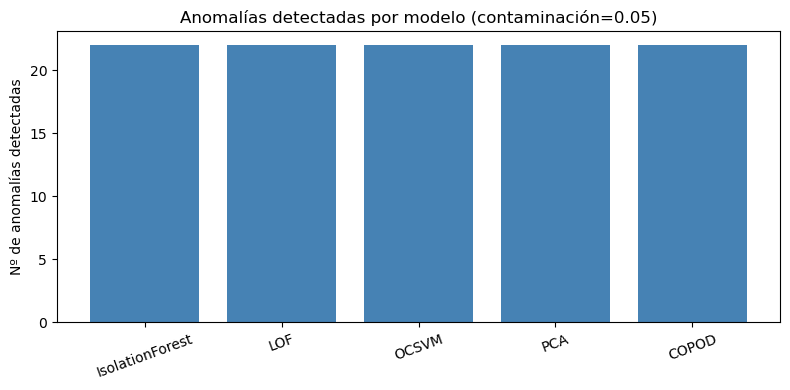

In [11]:
summary_table = summarize_detection(results_spec)
display(summary_table)
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_table['Modelo'], summary_table['Anomalías detectadas'], color='steelblue')
ax.set_ylabel('Nº de anomalías detectadas')
ax.set_title(f'Anomalías detectadas por modelo (contaminación={CONTAMINATION})')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close(fig)

### 3.2 Solapamiento entre modelos (índice de Jaccard)

,IsolationForest,LOF,OCSVM,PCA,COPOD
IsolationForest,1.000,0.571,0.692,0.760,0.419
LOF,0.571,1.000,0.571,0.517,0.375
OCSVM,0.692,0.571,1.000,0.833,0.630
PCA,0.760,0.517,0.833,1.000,0.571
COPOD,0.419,0.375,0.630,0.571,1.000


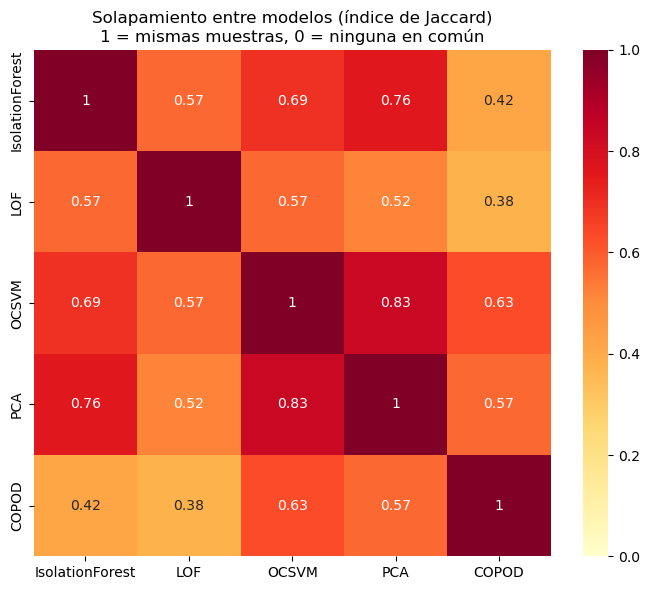

In [12]:
overlap = overlap_matrix(results_spec)
display(overlap)
 
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(overlap.astype(float), annot=True, cmap='YlOrRd', vmin=0, vmax=1, ax=ax)
ax.set_title('Solapamiento entre modelos (índice de Jaccard)\n1 = mismas muestras, 0 = ninguna en común')
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Consenso de anomalías

Muestras marcadas como anomalía de consenso (≥3/5 modelos): 21 (4.9%)


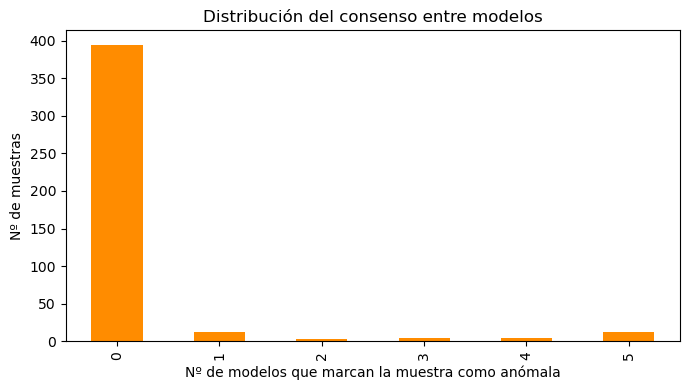

In [13]:
# Una muestra se considera anomalía "de consenso" si al menos 3 de los 5
# modelos coinciden en marcarla. Esto es más robusto que confiar en un único
# algoritmo, ya que cada método tiene sesgos distintos (LOF es local, IForest
# es global, OCSVM depende del kernel, etc.)
MIN_MODELS = 3
 
consensus = consensus_anomalies(results_spec, min_models=MIN_MODELS)
n_consensus = int(consensus['is_consensus_anomaly'].sum())
 
print(f"Muestras marcadas como anomalía de consenso (≥{MIN_MODELS}/5 modelos): {n_consensus} "
      f"({100*n_consensus/len(consensus):.1f}%)")

consensus.to_csv(Path('results') / 'consensus_pyod.csv')
 
# Distribución de cuántos modelos coinciden por muestra
fig, ax = plt.subplots(figsize=(7, 4))
consensus['n_models_flagged'].value_counts().sort_index().plot(kind='bar', color='darkorange', ax=ax)
ax.set_xlabel('Nº de modelos que marcan la muestra como anómala')
ax.set_ylabel('Nº de muestras')
ax.set_title('Distribución del consenso entre modelos')
plt.tight_layout()
plt.show()
plt.close(fig)

## 5. Validación de las anomalías encontradas
### 5.1 ¿Las anomalías de consenso tienen calidad química distinta?

In [ ]:
target_cols_all = [c for c in ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1']
                    if c in df_raw.columns]
 
df_train_full = df_raw.loc[df_raw.index.intersection(X_train.index)]
 
quality_check = crosscheck_with_target(df_train_full, consensus, target_cols_all)
display(quality_check)
 
print("\nInterpretación:")
for _, row in quality_check.iterrows():
    if row['diferencia_significativa']:
        print(f"  → {row['target']}: diferencia SIGNIFICATIVA entre anomalías y muestras normales "
              f"(p={row['p_value']})")
    else:
        print(f"  → {row['target']}: sin diferencia significativa (p={row['p_value']})")

,target,media_anomalias,media_normales,n_anomalias,n_normales,p_value,diferencia_significativa
0,tss_,8.095,8.109,21,410,0.8041,False
1,ta_g_100ml-1,5.783,5.953,21,405,0.4409,False
2,tpc_peel_mg_100_g1,312.308,305.635,21,410,0.7959,False
3,tpc_juice_mg_100_ml1,47.573,53.774,21,409,0.0038,True



Interpretación:
  → tss_: sin diferencia significativa (p=0.8041)
  → ta_g_100ml-1: sin diferencia significativa (p=0.4409)
  → tpc_peel_mg_100_g1: sin diferencia significativa (p=0.7959)
  → tpc_juice_mg_100_ml1: diferencia SIGNIFICATIVA entre anomalías y muestras normales (p=0.0038)


### 5.2 Visualización: PCA 2D coloreado por consenso

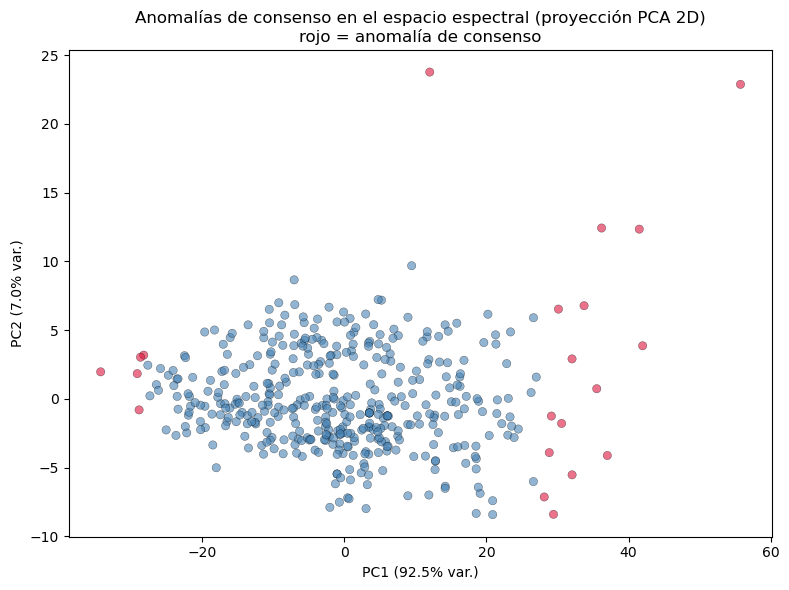

In [15]:
from sklearn.decomposition import PCA as SklearnPCA
 
pca_2d = SklearnPCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_spec)
 
fig, ax = plt.subplots(figsize=(8, 6))
colors = consensus['is_consensus_anomaly'].map({True: 'crimson', False: 'steelblue'})
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.6, edgecolors='k', linewidths=0.3)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title('Anomalías de consenso en el espacio espectral (proyección PCA 2D)\nrojo = anomalía de consenso')
plt.tight_layout()
plt.show()
plt.close(fig)

## 6. Comparación con los métodos univariantes clásicos (notebook 1)

In [16]:
# Se comprueba si las anomalías de consenso de PyOD coinciden con los
# outliers detectados por IQR en las variables morfológicas (notebook 1,
# sección 3.2). Si coinciden mucho, ambos enfoques refuerzan la misma
# conclusión; si no, PyOD está capturando un tipo de anomalía distinto
# (multivariante/espectral) que los métodos univariantes no podían ver.
from src.outliers import univariate_outlier_table
 
morf_cols_present = [c for c in data_bundle['morf_cols'] if c in df_train_full.columns]
 
outlier_flags_univariate = pd.DataFrame(index=df_train_full.index)
for col in morf_cols_present:
    serie = pd.to_numeric(df_train_full[col], errors='coerce').dropna()
    q1, q3 = np.percentile(serie, [25, 75])
    iqr = q3 - q1
    outlier_flags_univariate[f'{col}_outlier'] = (
        (df_train_full[col] < q1 - 1.5*iqr) | (df_train_full[col] > q3 + 1.5*iqr)
    )
outlier_flags_univariate['es_outlier_univariante'] = outlier_flags_univariate.any(axis=1)
 
comparison_idx = consensus.index.intersection(outlier_flags_univariate.index)
crosstab_methods = pd.crosstab(
    outlier_flags_univariate.loc[comparison_idx, 'es_outlier_univariante'],
    consensus.loc[comparison_idx, 'is_consensus_anomaly'],
    rownames=['Outlier univariante (IQR, notebook 1)'],
    colnames=['Anomalía de consenso PyOD'],
)
print("Tabla de contingencia — métodos clásicos vs PyOD:")
display(crosstab_methods)
 
n_solo_pyod = int(crosstab_methods.loc[False, True]) if (False in crosstab_methods.index and True in crosstab_methods.columns) else 0
print(f"\n{n_solo_pyod} muestras son detectadas SOLO por PyOD (no por IQR univariante).")
print("Esto sugiere que PyOD captura anomalías multivariantes/espectrales "
      "que los métodos univariantes no pueden ver al analizar una variable a la vez.")

Tabla de contingencia — métodos clásicos vs PyOD:


Anomalía de consenso PyOD,False,True
"Outlier univariante (IQR, notebook 1)",,
False,395,14
True,15,7



14 muestras son detectadas SOLO por PyOD (no por IQR univariante).
Esto sugiere que PyOD captura anomalías multivariantes/espectrales que los métodos univariantes no pueden ver al analizar una variable a la vez.
